In [1]:
# Kütüphanelerin yüklenmesi
import pandas as pd
import numpy as np

# Veri setinin okunması
df = pd.read_csv("sleep_data.csv")

# İlk 5 satırın görüntülenmesi
print("--- VERİ SETİ ÖNİZLEMESİ ---")
display(df.head())

# Veri seti hakkında genel bilgi (Eksik veri var mı, veri tipleri ne?)
print("\n--- VERİ SETİ BİLGİSİ ---")
df.info()

--- VERİ SETİ ÖNİZLEMESİ ---


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



--- VERİ SETİ BİLGİSİ ---
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [2]:
# 1. Gereksiz sütunu veriden çıkarma
df = df.drop('Person ID', axis=1)

# 2. Uyku bozukluğu olmayan kişilerin boşluklarını 'None' ile doldurma
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 3. Tansiyon verisini '/' işaretinden ikiye bölme (Büyük ve Küçük tansiyon)
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)

# Yeni oluşan sütunları metinden (string), tam sayıya (integer) çevirme
df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

# İşimiz biten eski metin tabanlı tansiyon sütununu silme
df = df.drop('Blood Pressure', axis=1)

# Temizlik sonrası yeni durumu kontrol edelim
print("--- TEMİZLİK SONRASI VERİ SETİ ---")
df.info()

--- TEMİZLİK SONRASI VERİ SETİ ---
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    str    
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    str    
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    str    
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    str    
 11  Systolic_BP              374 non-null    int64  
 12  Diastolic_BP             374 non-null    int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 38.1 KB


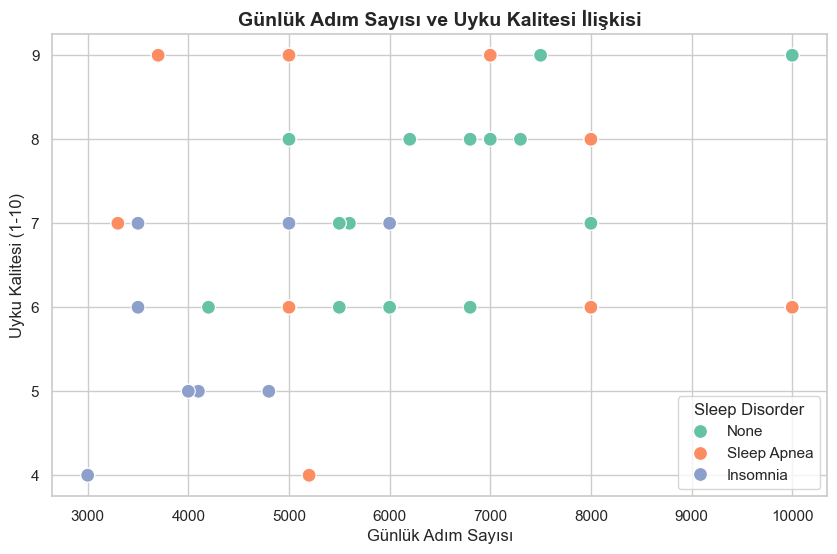

C:\Users\aybik\AppData\Local\Temp\ipykernel_12020\1174825423.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Occupation", y="Stress Level", palette="pastel")


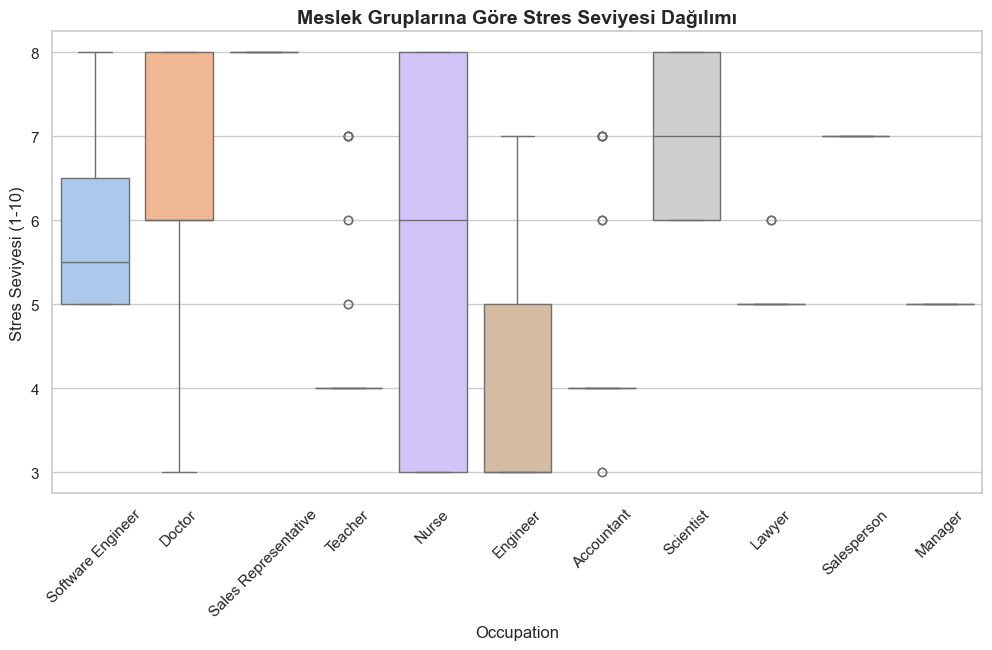

C:\Users\aybik\AppData\Local\Temp\ipykernel_12020\1174825423.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sleep Disorder", palette="viridis")


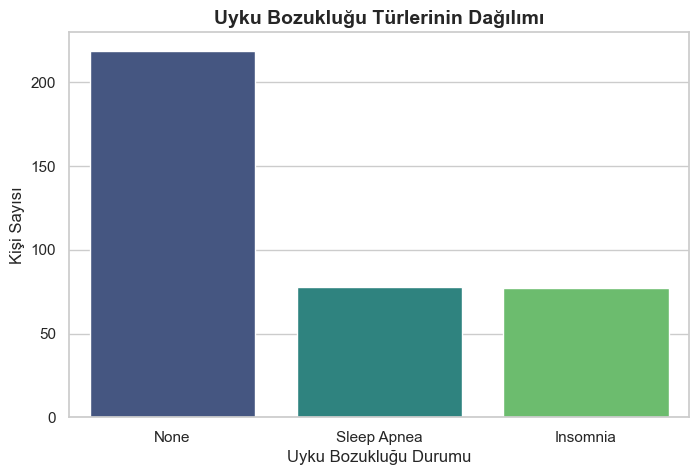

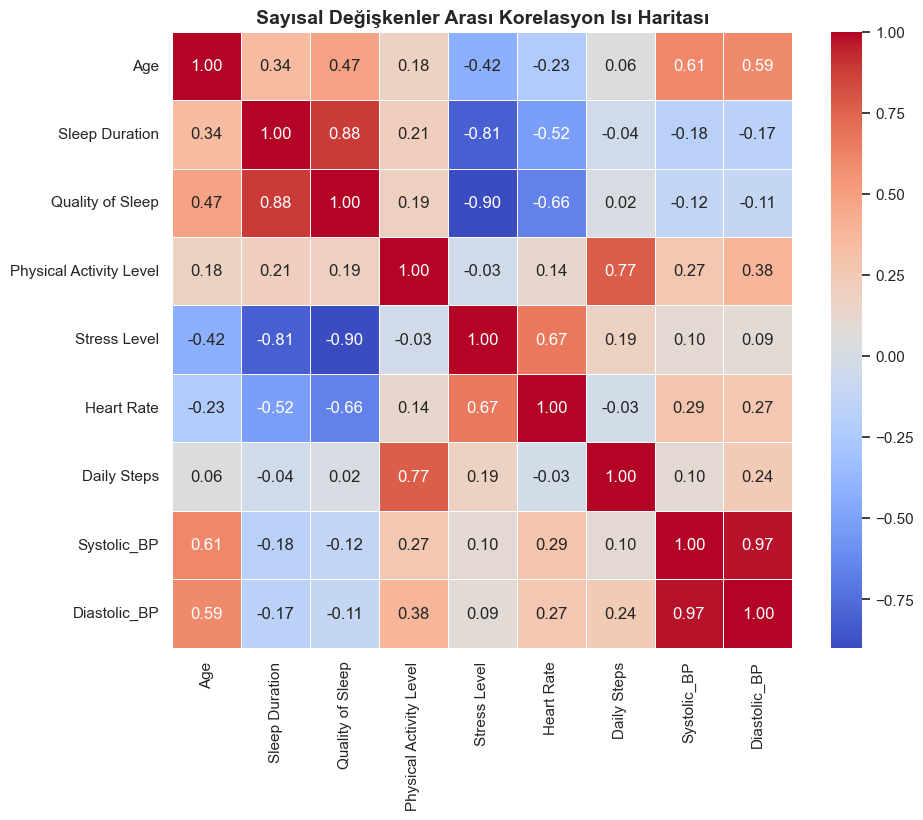

In [3]:
# Gerekli görselleştirme kütüphanelerinin yüklenmesi
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin genel arka plan stilini temiz ve şık ayarlayalım
sns.set_theme(style="whitegrid")

# 1. Grafik: Günlük Adım Sayısı vs Uyku Kalitesi (Saçılım Grafiği)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Daily Steps", y="Quality of Sleep", hue="Sleep Disorder", palette="Set2", s=100)
plt.title("Günlük Adım Sayısı ve Uyku Kalitesi İlişkisi", fontsize=14, fontweight='bold')
plt.xlabel("Günlük Adım Sayısı")
plt.ylabel("Uyku Kalitesi (1-10)")
plt.show()

# 2. Grafik: Mesleklere Göre Stres Seviyesi (Kutu Grafiği)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Occupation", y="Stress Level", palette="pastel")
plt.title("Meslek Gruplarına Göre Stres Seviyesi Dağılımı", fontsize=14, fontweight='bold')
plt.xticks(rotation=45) # Eksen yazıları birbirine girmesin diye 45 derece eğik yazdırıyoruz
plt.ylabel("Stres Seviyesi (1-10)")
plt.show()

# 3. Grafik: Uyku Bozukluğu Dağılımı (Sütun Grafiği)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Sleep Disorder", palette="viridis")
plt.title("Uyku Bozukluğu Türlerinin Dağılımı", fontsize=14, fontweight='bold')
plt.xlabel("Uyku Bozukluğu Durumu")
plt.ylabel("Kişi Sayısı")
plt.show()

# 4. Grafik: Değişkenler Arası Korelasyon (Isı Haritası)
plt.figure(figsize=(10, 8))
# Sadece sayısal (matematiksel) sütunları seçip aralarındaki matematiksel ilişkiyi hesaplıyoruz
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Sayısal Değişkenler Arası Korelasyon Isı Haritası", fontsize=14, fontweight='bold')
plt.show()

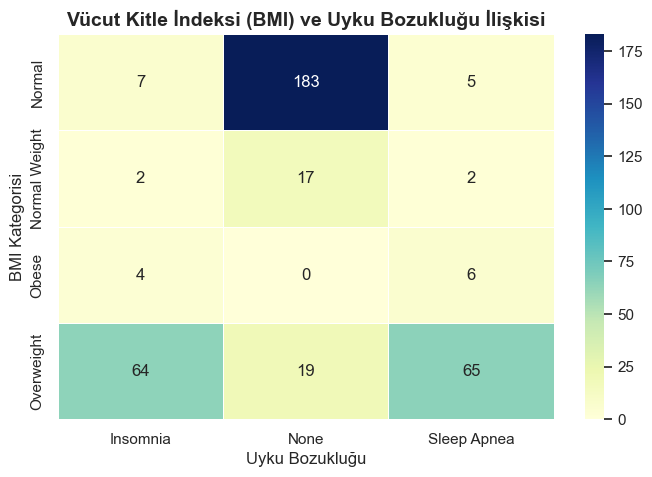

C:\Users\aybik\AppData\Local\Temp\ipykernel_12020\1380745793.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Age Group", y="Sleep Duration", palette="muted", inner="quartile")


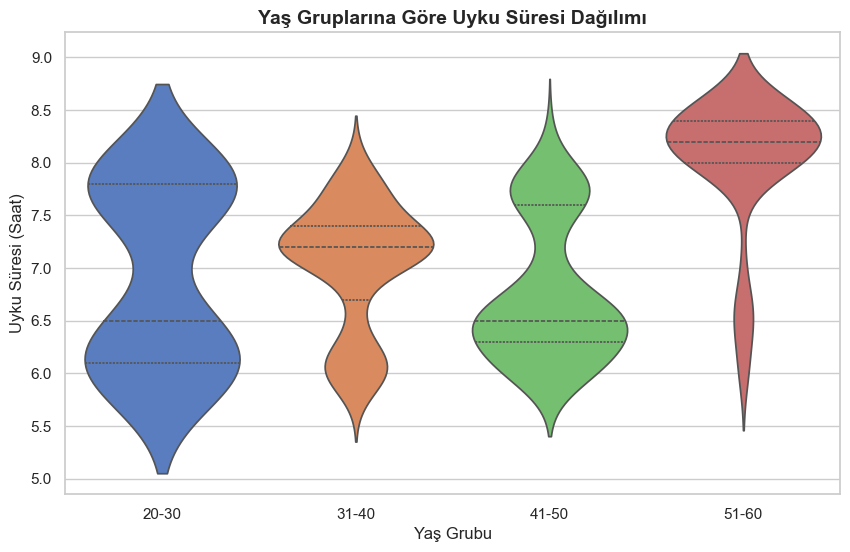

In [4]:
# 5. Grafik: BMI Kategorisi ve Uyku Bozukluğu (Çapraz Tablo Isı Haritası)
plt.figure(figsize=(8, 5))
# İki metin/kategori sütununun kesişim sayılarını buluyoruz
bmi_sleep_cross = pd.crosstab(df['BMI Category'], df['Sleep Disorder'])
sns.heatmap(bmi_sleep_cross, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)
plt.title("Vücut Kitle İndeksi (BMI) ve Uyku Bozukluğu İlişkisi", fontsize=14, fontweight='bold')
plt.xlabel("Uyku Bozukluğu")
plt.ylabel("BMI Kategorisi")
plt.show()

# 6. Grafik: Yaş ve Uyku Süresi Dağılımı (Keman Grafiği - Violin Plot)
# Yaşları daha rahat gruplamak için 10'luk dilimlere ayırıyoruz
df['Age Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], labels=['20-30', '31-40', '41-50', '51-60'])

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Age Group", y="Sleep Duration", palette="muted", inner="quartile")
plt.title("Yaş Gruplarına Göre Uyku Süresi Dağılımı", fontsize=14, fontweight='bold')
plt.xlabel("Yaş Grubu")
plt.ylabel("Uyku Süresi (Saat)")
plt.show()

In [5]:
# 1. Gerekli ML kütüphanelerinin yüklenmesi
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Metin tabanlı verileri bilgisayarın anlayacağı 1 ve 0'lara dönüştürme (One-Hot Encoding)
# Bilgisayar 'Male' veya 'Overweight' kelimelerini matematiksel işleyemez, bu yüzden onları sayı yaparız.
df_encoded = pd.get_dummies(df, columns=['Gender', 'Occupation', 'BMI Category'], drop_first=True)

# 3. Girdiler (X) ve Çıktının (y) Belirlenmesi
# X: Tahmin yaparken kullanacağımız tüm özellikler (Yaş, Stres, Nabız vb.)
# y: Tahmin etmek istediğimiz hedef sütun (Uyku Bozukluğu Var mı/Yok mu?)
X = df_encoded.drop(['Sleep Disorder', 'Age Group'], axis=1) # Hedef sütunları girdilerden çıkarıyoruz
y = df_encoded['Sleep Disorder']

# 4. Veriyi "Eğitim" ve "Test" olarak ikiye bölme (Train-Test Split)
# Verinin %80'ini modeli eğitmek için, %20'sini ise modeli sınav yapmak (test etmek) için saklıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Karar Ağacı Modelinin Oluşturulması ve Eğitilmesi
model = DecisionTreeClassifier(max_depth=3, random_state=42) # Çok karmaşık olmasın diye derinliği 3 yaptık
model.fit(X_train, y_train) # Öğrenme süreci burada gerçekleşiyor

# 6. Modelin Test Edilmesi ve Başarı Oranı
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("--- MODEL PERFORMANSI ---")
print(f"Modelin Doğruluk (Accuracy) Skoru: %{accuracy * 100:.2f}")
print("\n--- DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))

--- MODEL PERFORMANSI ---
Modelin Doğruluk (Accuracy) Skoru: %88.00

--- DETAYLI SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



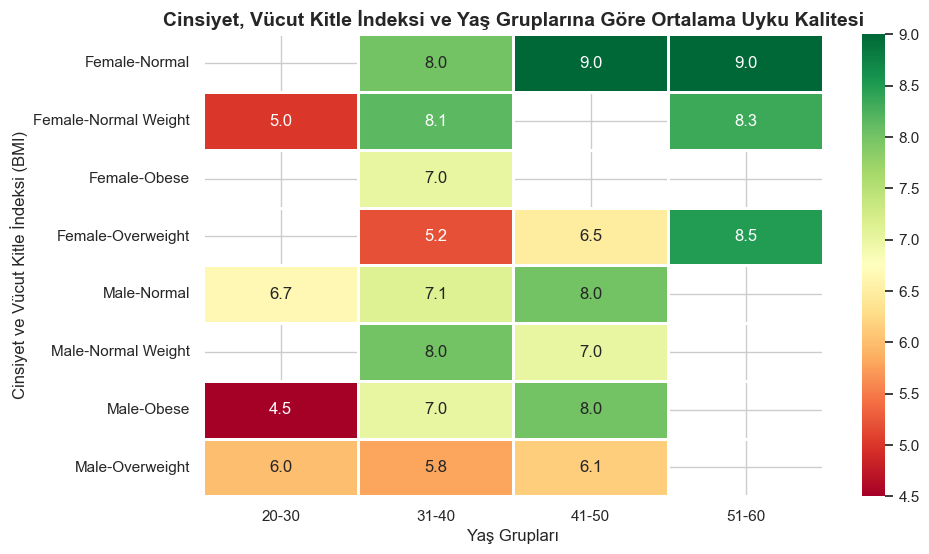

In [6]:
# 1. Yaşları 10'ar yıllık gruplara (kategorilere) ayırma
df['Age Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], labels=['20-30', '31-40', '41-50', '51-60'])

# 2. Çok Boyutlu Özet Tablo (Pivot Table) Oluşturma
# Satırlar (index): Cinsiyet ve BMI Kategorisi
# Sütunlar (columns): Yaş Grupları
# İçindeki Değerler (values): Uyku Kalitesi Ortalaması
pivot_tablo = df.pivot_table(values='Quality of Sleep', 
                             index=['Gender', 'BMI Category'], 
                             columns='Age Group', 
                             aggfunc='mean') # 'mean' ortalama al demektir

# 3. Tabloyu Görselleştirme (Isı Haritası)
plt.figure(figsize=(10, 6))
# cmap="RdYlGn" -> Kırmızıdan (Kötü Uyku), Yeşile (İyi Uyku) giden renk skalası
sns.heatmap(pivot_tablo, annot=True, cmap="RdYlGn", fmt=".1f", linewidths=1)
plt.title("Cinsiyet, Vücut Kitle İndeksi ve Yaş Gruplarına Göre Ortalama Uyku Kalitesi", fontsize=14, fontweight='bold')
plt.ylabel("Cinsiyet ve Vücut Kitle İndeksi (BMI)")
plt.xlabel("Yaş Grupları")
plt.show()

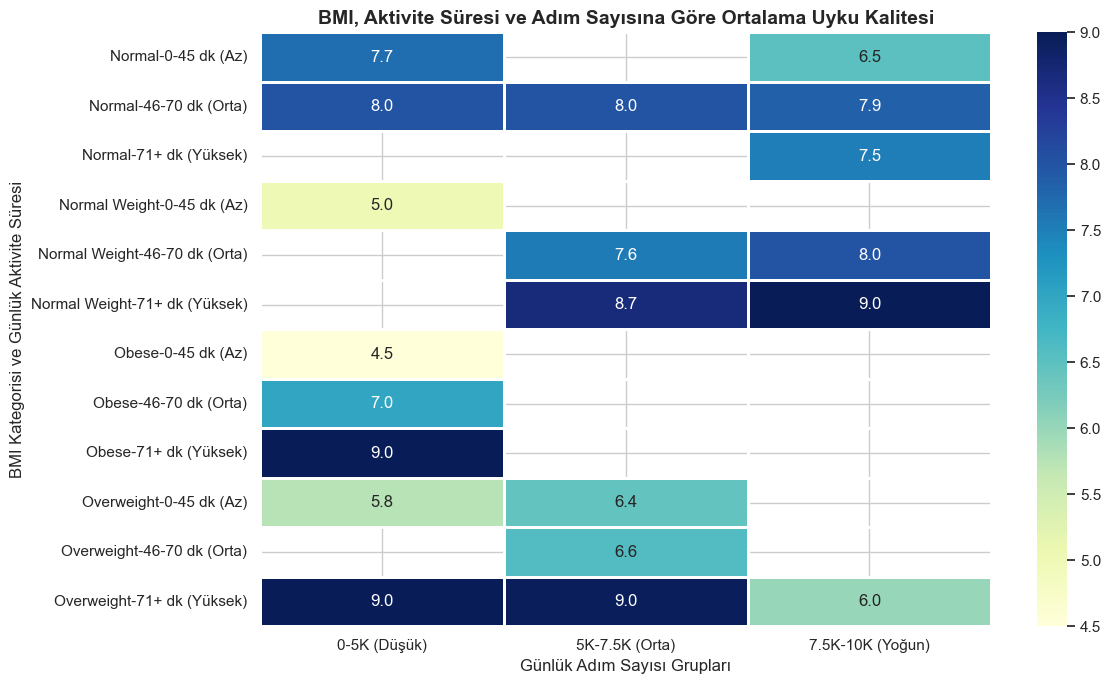

In [7]:
# 1. Günlük Adım Sayısını Gruplara Ayırma (Düşük, Orta, Yüksek, Çok Yüksek)
df['Steps Group'] = pd.cut(df['Daily Steps'], 
                           bins=[0, 5000, 7500, 10000, 15000], 
                           labels=['0-5K (Düşük)', '5K-7.5K (Orta)', '7.5K-10K (Yoğun)', '10K+ (Aktif)'])

# 2. Fiziksel Aktivite Süresini (Dakika) Gruplara Ayırma (Kısa, Orta, Uzun)
df['Activity Group'] = pd.cut(df['Physical Activity Level'], 
                              bins=[0, 45, 70, 100], 
                              labels=['0-45 dk (Az)', '46-70 dk (Orta)', '71+ dk (Yüksek)'])

# 3. Çok Boyutlu Özet Tabloyu Oluşturma
pivot_tablo_2 = df.pivot_table(values='Quality of Sleep', 
                               index=['BMI Category', 'Activity Group'], 
                               columns='Steps Group', 
                               aggfunc='mean')

# 4. Isı Haritası Olarak Görselleştirme
plt.figure(figsize=(12, 7))
# YlGnBu skalası: Sarıdan (Kötü/Düşük), Koyu Maviye (İyi/Yüksek) doğru gider
sns.heatmap(pivot_tablo_2, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=1)

plt.title("BMI, Aktivite Süresi ve Adım Sayısına Göre Ortalama Uyku Kalitesi", fontsize=14, fontweight='bold')
plt.ylabel("BMI Kategorisi ve Günlük Aktivite Süresi")
plt.xlabel("Günlük Adım Sayısı Grupları")
plt.tight_layout() # Grafik etiketlerinin ekrana tam sığması için
plt.show()


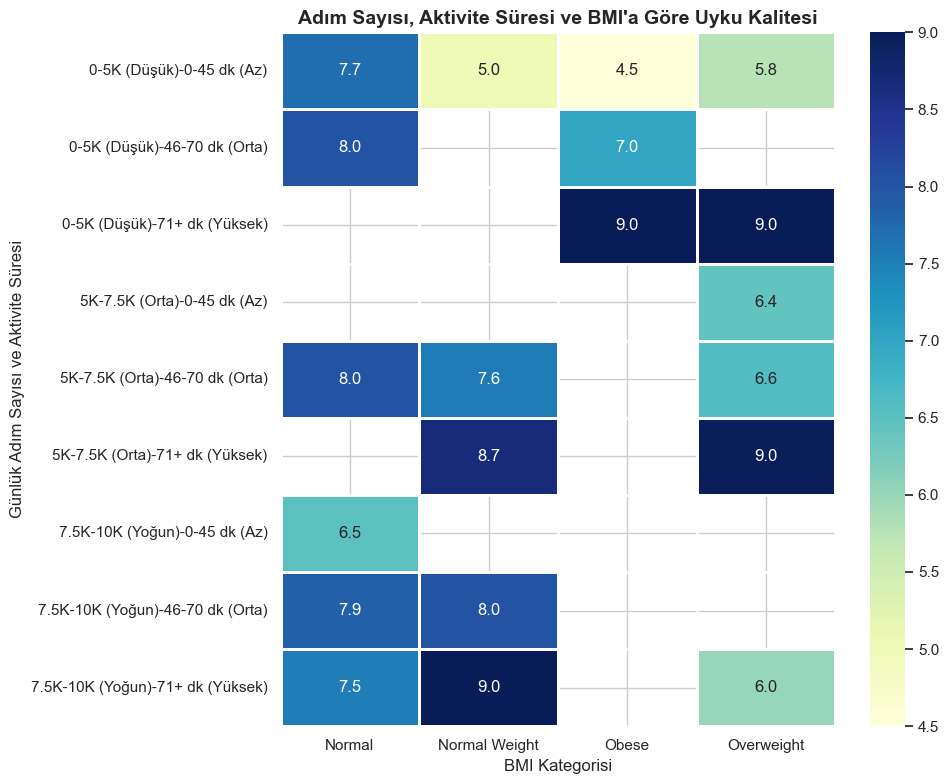

In [8]:
# Verilerimiz bir önceki adımda zaten gruplandığı için direkt tabloyu oluşturuyoruz

# Çok Boyutlu Özet Tabloyu Oluşturma (Yeni Eksenlere Göre)
# Satırlar (Y Eksen) : Adım Grubu ve Aktivite Grubu
# Sütunlar (X Eksen): BMI Kategorisi
pivot_tablo_3 = df.pivot_table(values='Quality of Sleep', 
                               index=['Steps Group', 'Activity Group'], 
                               columns='BMI Category', 
                               aggfunc='mean')

# Isı Haritası Olarak Görselleştirme
plt.figure(figsize=(10, 8)) # Y ekseni uzadığı için grafiğin boyunu biraz uzattık (8 yaptık)
sns.heatmap(pivot_tablo_3, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=1)

# Eksen isimlerini ve başlığı yeni düzene göre güncelleyelim
plt.title("Adım Sayısı, Aktivite Süresi ve BMI'a Göre Uyku Kalitesi", fontsize=14, fontweight='bold')
plt.ylabel("Günlük Adım Sayısı ve Aktivite Süresi")
plt.xlabel("BMI Kategorisi")
plt.tight_layout() 
plt.show()


In [ ]:
# Veri Bütünlüğü Kontrolü: Veri seti incelenirken "45 dakika fiziksel aktivite" ve "10.000 günlük
# adım" gibi kombinasyonların tutarlılığı sorgulanmış; ancak adım sayısının 24 saatlik birikimi,
# aktivite süresinin ise spesifik egzersiz eforunu temsil ettiği anlaşıldığından bu veriler doğal kabul
# edilerek veri setinde tutulmuştur.

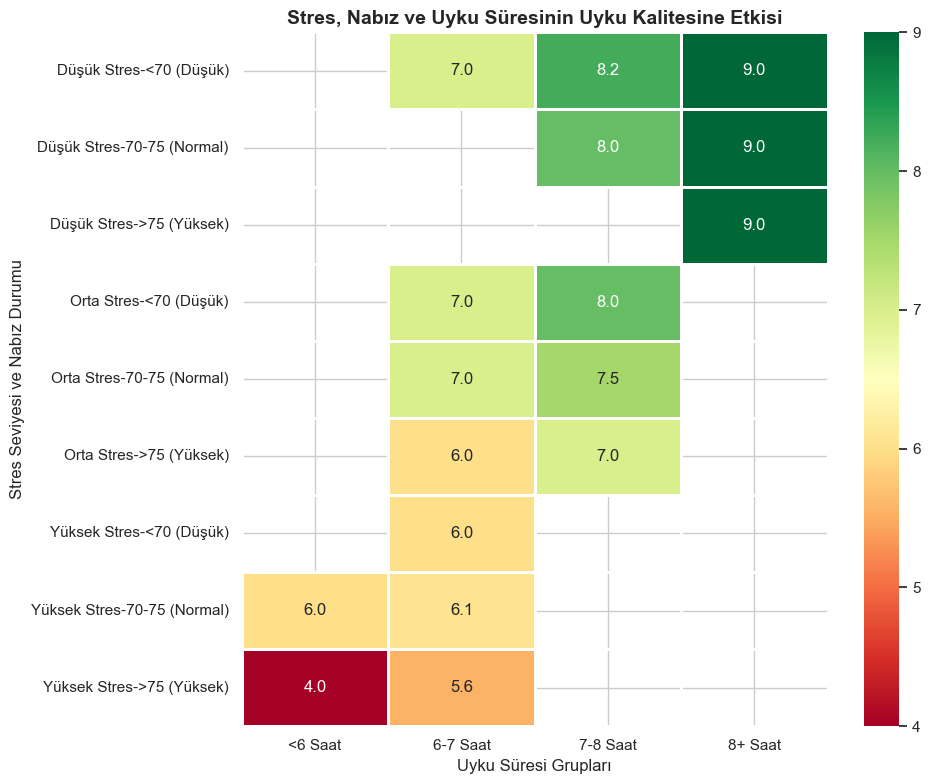

In [9]:
# 1. Uyku Süresini Gruplama (Saat bazında)
df['Duration Group'] = pd.cut(df['Sleep Duration'], 
                              bins=[0, 6, 7, 8, 24], 
                              labels=['<6 Saat', '6-7 Saat', '7-8 Saat', '8+ Saat'])

# 2. Nabız (Heart Rate) Değerlerini Gruplama (Dinlenik nabız mantığına göre)
df['HR Group'] = pd.cut(df['Heart Rate'], 
                        bins=[0, 69, 75, 150], 
                        labels=['<70 (Düşük)', '70-75 (Normal)', '>75 (Yüksek)'])

# 3. Stres Seviyesini Gruplama (1-10 arası skoru 3 kategoriye ayırma)
df['Stress Group'] = pd.cut(df['Stress Level'], 
                            bins=[0, 4, 6, 10], 
                            labels=['Düşük Stres', 'Orta Stres', 'Yüksek Stres'])

# 4. Çok Boyutlu Özet Tabloyu Oluşturma
pivot_tablo_4 = df.pivot_table(values='Quality of Sleep', 
                               index=['Stress Group', 'HR Group'], 
                               columns='Duration Group', 
                               aggfunc='mean')

# 5. Isı Haritası Olarak Görselleştirme
plt.figure(figsize=(10, 8))
# RdYlGn: Kırmızı (Kötü Uyku Kalitesi), Sarı (Orta), Yeşil (İyi Uyku Kalitesi)
sns.heatmap(pivot_tablo_4, annot=True, cmap="RdYlGn", fmt=".1f", linewidths=1)

plt.title("Stres, Nabız ve Uyku Süresinin Uyku Kalitesine Etkisi", fontsize=14, fontweight='bold')
plt.ylabel("Stres Seviyesi ve Nabız Durumu")
plt.xlabel("Uyku Süresi Grupları")
plt.tight_layout()
plt.show()

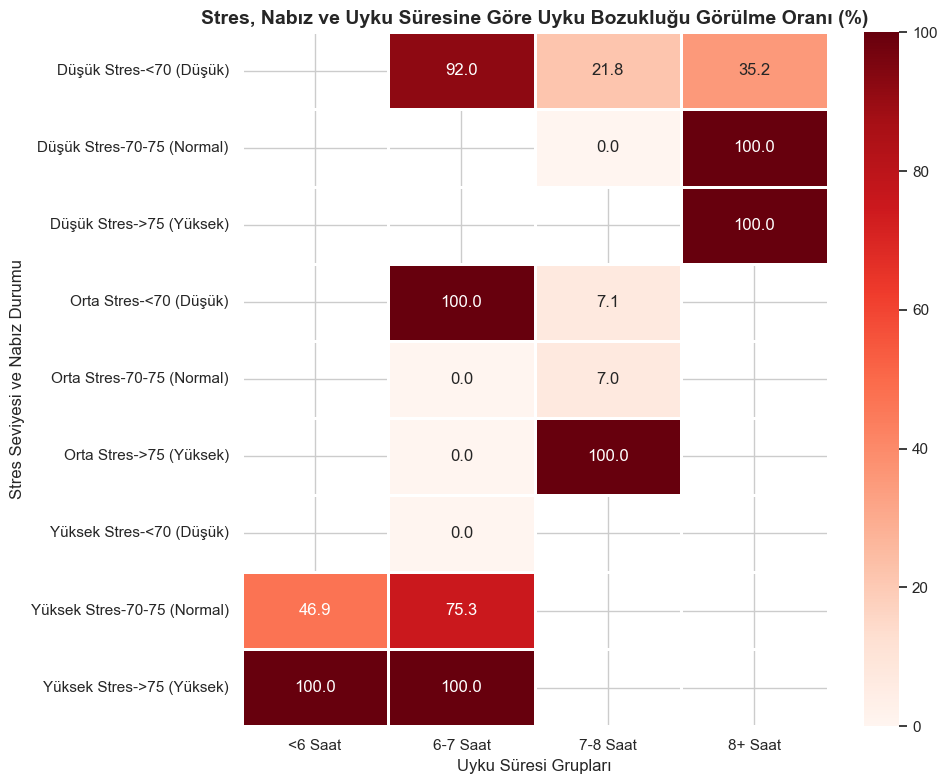

In [10]:
# 1. Hastalık Oranını Yüzde Olarak Hesaplamak İçin Hile Sütunu
# 'None' olanlara 0, olmayanlara (yani hastalara) 100 veriyoruz.
df['Disorder_Percentage'] = (df['Sleep Disorder'] != 'None').astype(int) * 100

# 2. Çok Boyutlu Özet Tabloyu Oluşturma (Bu kez değerler hastalık yüzdesi)
pivot_tablo_5 = df.pivot_table(values='Disorder_Percentage', 
                               index=['Stress Group', 'HR Group'], 
                               columns='Duration Group', 
                               aggfunc='mean')

# 3. Isı Haritası Olarak Görselleştirme
plt.figure(figsize=(10, 8))
# cmap="Reds": Beyaz/Açık Pembe (%0 - Sağlıklı), Koyu Kırmızı (%100 - Kesin Hastalık)
sns.heatmap(pivot_tablo_5, annot=True, cmap="Reds", fmt=".1f", linewidths=1)

plt.title("Stres, Nabız ve Uyku Süresine Göre Uyku Bozukluğu Görülme Oranı (%)", fontsize=14, fontweight='bold')
plt.ylabel("Stres Seviyesi ve Nabız Durumu")
plt.xlabel("Uyku Süresi Grupları")
plt.tight_layout()
plt.show()

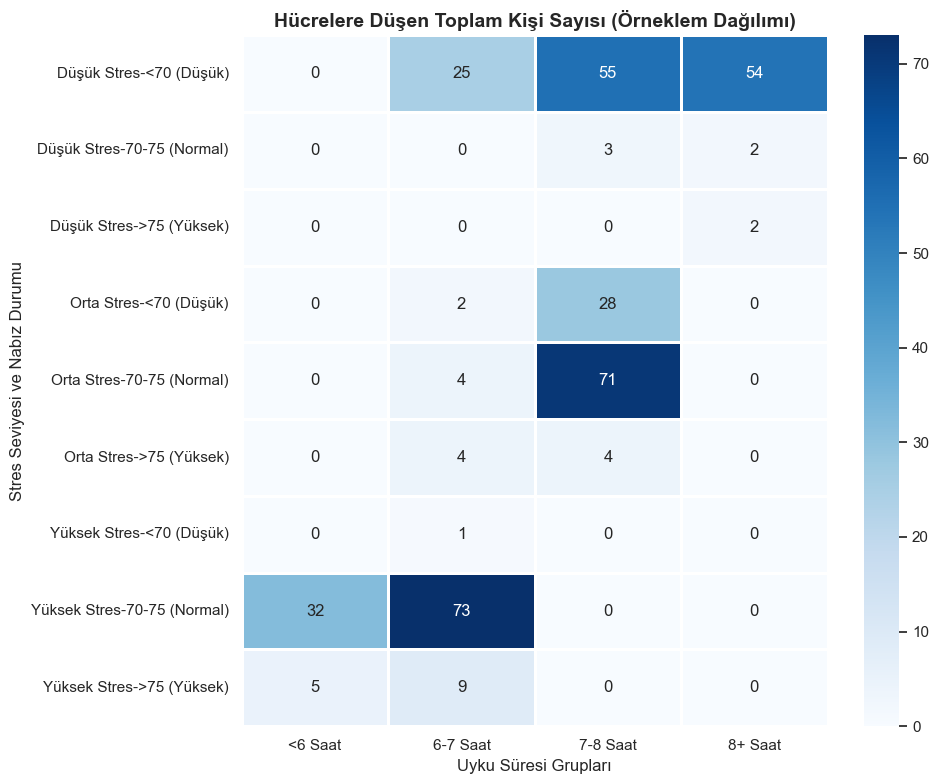

In [11]:
# Kutulara düşen kişi sayısını (boyutunu) hesaplayan pivot tablo
pivot_tablo_kisi_sayisi = df.pivot_table(index=['Stress Group', 'HR Group'], 
                                         columns='Duration Group', 
                                         aggfunc='size') # size: o gruba giren kişi sayısını sayar

# Boş (NaN) kalan hücreleri 0 ile dolduralım ki görselde güzel dursun
pivot_tablo_kisi_sayisi = pivot_tablo_kisi_sayisi.fillna(0)

# Isı Haritası Olarak Görselleştirme
plt.figure(figsize=(10, 8))
# Sadece tam sayıları görmek için fmt="g" (veya ".0f") kullanıyoruz
sns.heatmap(pivot_tablo_kisi_sayisi, annot=True, cmap="Blues", fmt=".0f", linewidths=1)

plt.title("Hücrelere Düşen Toplam Kişi Sayısı (Örneklem Dağılımı)", fontsize=14, fontweight='bold')
plt.ylabel("Stres Seviyesi ve Nabız Durumu")
plt.xlabel("Uyku Süresi Grupları")
plt.tight_layout()
plt.show()

In [12]:
# 1. Sadece seçtiğimiz 4 kritik fizyolojik özelliği filtreliyoruz (Feature Selection)
X_focused = df[['Stress Level', 'Heart Rate', 'Sleep Duration', 'Quality of Sleep']]
y = df['Sleep Disorder']

# 2. Veriyi yine %80 Eğitim, %20 Test olarak bölüyoruz
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_focused, y, test_size=0.2, random_state=42)

# 3. Yeni odaklanmış modelimizi oluşturma ve eğitme
model_focused = DecisionTreeClassifier(max_depth=3, random_state=42)
model_focused.fit(X_train_f, y_train_f)

# 4. Modelin test verisiyle tahmin yapması ve performans ölçümü
y_pred_f = model_focused.predict(X_test_f)
accuracy_f = accuracy_score(y_test_f, y_pred_f)

print("--- ODAKLANMIŞ YENİ MODEL PERFORMANSI ---")
print(f"Yeni Modelin Doğruluk (Accuracy) Skoru: %{accuracy_f * 100:.2f}")
print("\n--- YENİ DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test_f, y_pred_f))

--- ODAKLANMIŞ YENİ MODEL PERFORMANSI ---
Yeni Modelin Doğruluk (Accuracy) Skoru: %85.33

--- YENİ DETAYLI SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

    Insomnia       0.68      0.81      0.74        16
        None       0.95      0.93      0.94        43
 Sleep Apnea       0.79      0.69      0.73        16

    accuracy                           0.85        75
   macro avg       0.81      0.81      0.81        75
weighted avg       0.86      0.85      0.85        75

